# Final End-to-End Experiments: DINO vs SegNeXt-inspired

This notebook performs the full experimental pipeline:
1. clean dataset extraction
2. experiment setup
3. model training
4. metric collection
5. plot generation
6. result tables
7. qualitative comparisons

In [53]:
from pathlib import Path
import os
import re
import json
import random
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import display, Markdown

repo_root = Path.home() / "projects" / "inf367" / "INF367A-26V-Recod.ai-LUC-Forgery-Kaggle"
os.chdir(repo_root)

print("Current directory:", Path.cwd())
print("Outputs exists:", Path("outputs").exists())
print("Data exists:", Path("data").exists())

Current directory: /home/jovyan/projects/inf367/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle
Outputs exists: True
Data exists: True


In [54]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1JZUmMVeaT3mnjplj5kAVTgVkV77CBKoE/view" -O data/recodai-luc-scientific-image-forgery-detection.zip
!ls -lh data

Downloading...
From (original): https://drive.google.com/uc?id=1JZUmMVeaT3mnjplj5kAVTgVkV77CBKoE
From (redirected): https://drive.google.com/uc?id=1JZUmMVeaT3mnjplj5kAVTgVkV77CBKoE&confirm=t&uuid=4720bbae-b8f2-4bdd-838e-bd1730555120
To: /home/jovyan/projects/inf367/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle/data/recodai-luc-scientific-image-forgery-detection.zip
100%|██████████████████████████████████████| 5.21G/5.21G [02:26<00:00, 35.6MB/s]
total 4.9G
-rw-rw-r--. 1 jovyan users   71 Apr  9 17:03 README.md
-rw-r--r--. 1 jovyan users 4.9G Jan 20 11:42 recodai-luc-scientific-image-forgery-detection.zip


In [55]:
import zipfile
from pathlib import Path
from collections import Counter

zip_path = Path("data/recodai-luc-scientific-image-forgery-detection.zip")

with zipfile.ZipFile(zip_path) as zf:
    names = zf.namelist()

print("total entries:", len(names))

patterns = [
    "train_images/",
    "train_masks/",
    "supplemental_images/",
    "supplemental_masks/",
    "test_images/",
    "images/",
    "masks/",
]
for p in patterns:
    c = sum(1 for n in names if n.startswith(p))
    print(f"{p}: {c}")

print("\nTop-level prefixes:")
top = Counter(n.split("/")[0] for n in names if "/" in n)
for k, v in top.items():
    print(k, v)

total entries: 7977
train_images/: 5128
train_masks/: 2751
supplemental_images/: 48
supplemental_masks/: 48
test_images/: 1
images/: 0
masks/: 0

Top-level prefixes:
supplemental_images 48
supplemental_masks 48
test_images 1
train_images 5128
train_masks 2751


In [56]:
!pip install -q -U timm

In [57]:
from pathlib import Path

Path("scripts").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

In [58]:
segnext_code = r'''
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBN(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size, stride: int = 1, padding=0, groups: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False,
            ),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class MSCA(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

        self.local = ConvBN(channels, channels, kernel_size=5, padding=2, groups=channels)

        self.branch7 = nn.Sequential(
            ConvBN(channels, channels, kernel_size=(1, 7), padding=(0, 3), groups=channels),
            ConvBN(channels, channels, kernel_size=(7, 1), padding=(3, 0), groups=channels),
        )
        self.branch11 = nn.Sequential(
            ConvBN(channels, channels, kernel_size=(1, 11), padding=(0, 5), groups=channels),
            ConvBN(channels, channels, kernel_size=(11, 1), padding=(5, 0), groups=channels),
        )
        self.branch21 = nn.Sequential(
            ConvBN(channels, channels, kernel_size=(1, 21), padding=(0, 10), groups=channels),
            ConvBN(channels, channels, kernel_size=(21, 1), padding=(10, 0), groups=channels),
        )

        self.channel_mixer = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        x = self.proj(x)
        local_feat = self.local(x)
        att = local_feat + self.branch7(local_feat) + self.branch11(local_feat) + self.branch21(local_feat)
        att = self.channel_mixer(att)
        return identity * att


class ConvFFN(nn.Module):
    def __init__(self, channels: int, mlp_ratio: float = 4.0):
        super().__init__()
        hidden_dim = int(channels * mlp_ratio)
        self.fc1 = nn.Conv2d(channels, hidden_dim, kernel_size=1)
        self.dwconv = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1, groups=hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Conv2d(hidden_dim, channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.dwconv(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


class MSCANBlock(nn.Module):
    def __init__(self, channels: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.BatchNorm2d(channels)
        self.attn = MSCA(channels)
        self.norm2 = nn.BatchNorm2d(channels)
        self.ffn = ConvFFN(channels, mlp_ratio=mlp_ratio)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class DownsampleLayer(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class MSCANEncoder(nn.Module):
    def __init__(
        self,
        in_ch: int = 3,
        dims: tuple[int, int, int, int] = (32, 64, 160, 256),
        depths: tuple[int, int, int, int] = (2, 2, 4, 2),
        mlp_ratio: float = 4.0,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, dims[0], kernel_size=7, stride=4, padding=3, bias=False),
            nn.BatchNorm2d(dims[0]),
            nn.GELU(),
        )

        self.stage1 = nn.Sequential(*[MSCANBlock(dims[0], mlp_ratio=mlp_ratio) for _ in range(depths[0])])
        self.down1 = DownsampleLayer(dims[0], dims[1])

        self.stage2 = nn.Sequential(*[MSCANBlock(dims[1], mlp_ratio=mlp_ratio) for _ in range(depths[1])])
        self.down2 = DownsampleLayer(dims[1], dims[2])

        self.stage3 = nn.Sequential(*[MSCANBlock(dims[2], mlp_ratio=mlp_ratio) for _ in range(depths[2])])
        self.down3 = DownsampleLayer(dims[2], dims[3])

        self.stage4 = nn.Sequential(*[MSCANBlock(dims[3], mlp_ratio=mlp_ratio) for _ in range(depths[3])])

        self.channels = dims

    def forward(self, x: torch.Tensor):
        f1 = self.stage1(self.stem(x))
        f2 = self.stage2(self.down1(f1))
        f3 = self.stage3(self.down2(f2))
        f4 = self.stage4(self.down3(f3))
        return f1, f2, f3, f4


def _resolve_timm_model_name(requested_name: str, timm_module):
    available = set(timm_module.list_models())

    if requested_name in available:
        return requested_name

    alias_groups = {
        "mscan_tiny": ["mscan_tiny", "mscan_t", "segnext_tiny", "segnext_t"],
        "mscan_small": ["mscan_small", "mscan_s", "segnext_small", "segnext_s"],
        "mscan_base": ["mscan_base", "mscan_b", "segnext_base", "segnext_b"],
        "mscan_large": ["mscan_large", "mscan_l", "segnext_large", "segnext_l"],
    }

    candidates = alias_groups.get(requested_name, [requested_name])
    for name in candidates:
        if name in available:
            print(f"[TimmMSCANEncoder] Requested '{requested_name}' not found. Using '{name}' instead.")
            return name

    partial_matches = sorted([m for m in available if "mscan" in m or "segnext" in m or "convnext" in m])
    raise RuntimeError(
        f"Requested timm model '{requested_name}' not found. "
        f"Available related models: {partial_matches[:50]}"
    )


class TimmMSCANEncoder(nn.Module):
    def __init__(
        self,
        model_name: str = "convnext_tiny",
        pretrained: bool = True,
        in_ch: int = 3,
    ):
        super().__init__()
        try:
            import timm
        except ImportError as e:
            raise ImportError("timm is required for pretrained encoder. Please run `pip install -U timm`.") from e

        if pretrained and in_ch != 3:
            raise ValueError("Pretrained timm weights currently expect RGB input (in_ch=3).")

        resolved_name = _resolve_timm_model_name(model_name, timm)

        self.backbone = timm.create_model(
            resolved_name,
            features_only=True,
            pretrained=pretrained,
            in_chans=in_ch,
            out_indices=(0, 1, 2, 3),
        )
        self.channels = tuple(self.backbone.feature_info.channels())
        self.resolved_name = resolved_name

    def forward(self, x: torch.Tensor):
        feats = self.backbone(x)
        if len(feats) != 4:
            raise RuntimeError(f"Expected 4 feature maps from timm backbone, got {len(feats)}")
        return feats[0], feats[1], feats[2], feats[3]


class SimpleSegNeXtDecoder(nn.Module):
    def __init__(self, in_channels: tuple[int, int, int], decoder_dim: int = 128, out_ch: int = 1):
        super().__init__()
        c2, c3, c4 = in_channels

        self.proj2 = nn.Conv2d(c2, decoder_dim, kernel_size=1)
        self.proj3 = nn.Conv2d(c3, decoder_dim, kernel_size=1)
        self.proj4 = nn.Conv2d(c4, decoder_dim, kernel_size=1)

        self.fuse = nn.Sequential(
            nn.Conv2d(decoder_dim * 3, decoder_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(decoder_dim),
            nn.GELU(),
            nn.Dropout2d(0.1),
        )
        self.out_conv = nn.Conv2d(decoder_dim, out_ch, kernel_size=1)

    def forward(self, f2: torch.Tensor, f3: torch.Tensor, f4: torch.Tensor, target_size: tuple[int, int]) -> torch.Tensor:
        x2 = self.proj2(f2)
        x3 = F.interpolate(self.proj3(f3), size=f2.shape[-2:], mode="bilinear", align_corners=False)
        x4 = F.interpolate(self.proj4(f4), size=f2.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x2, x3, x4], dim=1)
        x = self.fuse(x)
        x = self.out_conv(x)
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
        return x


class SegNeXtSegmenter(nn.Module):
    def __init__(
        self,
        in_ch: int = 3,
        out_ch: int = 1,
        dims: tuple[int, int, int, int] = (32, 64, 160, 256),
        depths: tuple[int, int, int, int] = (2, 2, 4, 2),
        mlp_ratio: float = 4.0,
        decoder_dim: int = 128,
        encoder_source: str = "custom",
        timm_model_name: str = "convnext_tiny",
        pretrained_encoder: bool = False,
    ):
        super().__init__()

        if encoder_source == "custom":
            self.encoder = MSCANEncoder(
                in_ch=in_ch,
                dims=dims,
                depths=depths,
                mlp_ratio=mlp_ratio,
            )
            encoder_channels = self.encoder.channels
        elif encoder_source == "timm":
            self.encoder = TimmMSCANEncoder(
                model_name=timm_model_name,
                pretrained=pretrained_encoder,
                in_ch=in_ch,
            )
            encoder_channels = self.encoder.channels
        else:
            raise ValueError(f"Unsupported encoder_source: {encoder_source}")

        self.decoder = SimpleSegNeXtDecoder(
            in_channels=(encoder_channels[1], encoder_channels[2], encoder_channels[3]),
            decoder_dim=decoder_dim,
            out_ch=out_ch,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        target_size = x.shape[-2:]
        _, f2, f3, f4 = self.encoder(x)
        logits = self.decoder(f2, f3, f4, target_size=target_size)
        return logits
'''
Path("models/segnext_segmenter.py").write_text(segnext_code)
print("rewrote models/segnext_segmenter.py")

rewrote models/segnext_segmenter.py


In [59]:
extract_code = r'''
from pathlib import Path
import zipfile
import shutil
import argparse
import random


def safe_unlink(path: Path):
    try:
        if path.exists():
            path.unlink()
            print(f"Deleted zip: {path}")
    except Exception as e:
        print(f"Warning: could not delete zip {path}: {e}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--zip_path", type=str, required=True)
    parser.add_argument("--num_samples", type=int, required=True)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--delete_zip_after_extract", action="store_true")
    args = parser.parse_args()

    zip_path = Path(args.zip_path)
    data_dir = Path("data")

    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found: {zip_path}")

    shutil.rmtree(data_dir / "train_images", ignore_errors=True)
    shutil.rmtree(data_dir / "train_masks", ignore_errors=True)
    (data_dir / "train_images" / "forged").mkdir(parents=True, exist_ok=True)
    (data_dir / "train_masks").mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path) as zf:
        all_names = zf.namelist()

        forged_images = sorted(
            n for n in all_names
            if n.startswith("train_images/forged/") and n.endswith(".png")
        )
        all_masks = sorted(
            n for n in all_names
            if n.startswith("train_masks/") and n.endswith(".npy")
        )

        print(f"Found {len(forged_images)} forged train images in zip")
        print(f"Found {len(all_masks)} train masks in zip")

        if len(forged_images) == 0:
            raise RuntimeError("No files found under train_images/forged/")

        mask_ids = {Path(m).stem for m in all_masks}
        paired_images = [img for img in forged_images if Path(img).stem in mask_ids]

        print(f"Found {len(paired_images)} forged images with matching masks")

        if len(paired_images) == 0:
            raise RuntimeError("No forged images matched any mask IDs")

        rng = random.Random(args.seed)
        rng.shuffle(paired_images)

        selected_images = paired_images[:args.num_samples]
        selected_ids = {Path(n).stem for n in selected_images}
        matched_masks = [m for m in all_masks if Path(m).stem in selected_ids]

        print(f"Selected {len(selected_images)} forged images")
        print(f"Matched {len(matched_masks)} masks")

        for name in selected_images:
            with zf.open(name) as src:
                out_path = data_dir / "train_images" / "forged" / Path(name).name
                out_path.write_bytes(src.read())

        for name in matched_masks:
            with zf.open(name) as src:
                out_path = data_dir / "train_masks" / Path(name).name
                out_path.write_bytes(src.read())

    final_img_count = len(list((data_dir / "train_images" / "forged").glob("*.png")))
    final_mask_count = len(list((data_dir / "train_masks").glob("*.npy")))

    print(f"Final on disk -> images: {final_img_count}, masks: {final_mask_count}")

    if final_img_count == 0:
        raise RuntimeError("Extraction failed: no images were written to disk.")

    if args.delete_zip_after_extract:
        safe_unlink(zip_path)


if __name__ == "__main__":
    main()
'''
Path("scripts/extract_subset.py").write_text(extract_code)
print("wrote scripts/extract_subset.py")

wrote scripts/extract_subset.py


In [60]:
!python scripts/extract_subset.py --zip_path data/recodai-luc-scientific-image-forgery-detection.zip --num_samples 1000 --seed 42 --delete_zip_after_extract

Found 2751 forged train images in zip
Found 2751 train masks in zip
Found 2751 forged images with matching masks
Selected 1000 forged images
Matched 1000 masks
Final on disk -> images: 1000, masks: 1000
Deleted zip: data/recodai-luc-scientific-image-forgery-detection.zip


In [61]:
from pathlib import Path

forged_dir = Path("data/train_images/forged")
mask_dir = Path("data/train_masks")
zip_path = Path("data/recodai-luc-scientific-image-forgery-detection.zip")

print("zip exists after extraction:", zip_path.exists())
print("num forged png:", len(list(forged_dir.glob("*.png"))))
print("num masks:", len(list(mask_dir.glob("*.npy"))))

zip exists after extraction: False
num forged png: 1000
num masks: 1000


In [62]:
plot_code = r'''
from pathlib import Path
import json
import argparse
import matplotlib.pyplot as plt

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--run_dir", type=str, required=True)
    args = parser.parse_args()

    run_dir = Path(args.run_dir)
    metrics_path = run_dir / "metrics.json"
    if not metrics_path.exists():
        raise FileNotFoundError(f"metrics.json not found in {run_dir}")

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    epochs = [m["epoch"] for m in metrics]
    losses = [m["avg_loss"] for m in metrics]
    f1s = [m["val_f1"] for m in metrics]

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(run_dir / "loss_curve.png")
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, f1s, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation F1")
    plt.title("Validation F1")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(run_dir / "f1_curve.png")
    plt.close()

if __name__ == "__main__":
    main()
'''
Path("scripts/plot_metrics.py").write_text(plot_code)
print("wrote scripts/plot_metrics.py")

wrote scripts/plot_metrics.py


In [63]:
baseline_cfg = r'''
import os
import random
from dataclasses import dataclass

import numpy as np
import torch


@dataclass(frozen=True)
class BaselineConfig:
    num_epochs: int = 3
    batch_size: int = 2
    seed: int = 42
    target_size: int = 448
    pred_threshold: float = 0.5
    harden_temperature: float = 0.7
    hard_clip_low: float = 0.1
    hard_clip_high: float = 0.9
    min_component_area: int = 50
    train_subset: int = 200
    val_subset: int = 30
    lr: float = 1e-4
    grad_clip_max_norm: float = 1.0
    train_num_workers: int = 2
    val_num_workers: int = 1
    use_rgb: bool = True
    normalize_rgb: bool = True
    dino_mean: tuple[float, float, float] = (0.485, 0.456, 0.406)
    dino_std: tuple[float, float, float] = (0.229, 0.224, 0.225)
    dino_model_name: str = "dinov2_vitb14"
    dino_embed_dim: int = 768
    freeze_dino_encoder: bool = True

    model_type: str = "dino"

    segnext_dims: tuple[int, int, int, int] = (32, 64, 160, 256)
    segnext_depths: tuple[int, int, int, int] = (2, 2, 4, 2)
    segnext_mlp_ratio: float = 4.0
    segnext_decoder_dim: int = 128

    segnext_encoder_source: str = "custom"
    segnext_timm_model_name: str = "convnext_tiny"
    segnext_pretrained_encoder: bool = False

    use_amp: bool = True
    sliding_window_size: int | None = 448
    sliding_stride: int | None = 224
    sliding_batch_size: int = 8


def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
'''
Path("configs/baseline_config.py").write_text(baseline_cfg)
print("wrote configs/baseline_config.py")

wrote configs/baseline_config.py


In [64]:
train_code = r'''
from pathlib import Path
from functools import partial
import random
import json
import copy
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from models.segnext_segmenter import SegNeXtSegmenter
from configs.baseline_config import BaselineConfig, seed_worker, set_seed
from datasets.forgery_dataset import ForgeryDataset
from engine.train_loop import train_one_epoch
from engine.validate_loop import validate_one_epoch
from inference.sliding_window_dino import sliding_window_dino
from models.dino_segmenter import DinoSegmenter
from util.pixelmapUtil import PixelMapUtil


def get_forged_case_ids():
    forged_dir = Path("data/train_images/forged")
    return sorted([p.stem for p in forged_dir.glob("*.png")])


def split_ids(ids, val_ratio=0.1, seed=42):
    rng = random.Random(seed)
    ids = ids.copy()
    rng.shuffle(ids)
    n_val = int(len(ids) * val_ratio)
    return ids[n_val:], ids[:n_val]


def main():
    config = BaselineConfig()

    encoder_tag = ""
    if config.model_type == "segnext":
        if config.segnext_encoder_source == "timm":
            pt_tag = "pt" if config.segnext_pretrained_encoder else "scratch"
            encoder_tag = f"_{config.segnext_timm_model_name}_{pt_tag}"
        else:
            encoder_tag = "_custom"

    run_name = f"{config.model_type}{encoder_tag}_lr{config.lr}_seed{config.seed}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    output_dir = Path("outputs") / run_name
    output_dir.mkdir(parents=True, exist_ok=True)

    set_seed(config.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Using seed: {config.seed}")

    pixel_util = PixelMapUtil()
    all_ids = get_forged_case_ids()
    if len(all_ids) == 0:
        raise RuntimeError(
            "No forged training images found in data/train_images/forged. "
            "Run extraction first and keep the extracted files on disk."
        )
    train_ids, val_ids = split_ids(all_ids, val_ratio=0.1, seed=config.seed)

    train_ids = train_ids[: config.train_subset]
    val_ids = val_ids[: config.val_subset]

    config_dict = {
        "model_type": config.model_type,
        "num_epochs": config.num_epochs,
        "batch_size": config.batch_size,
        "seed": config.seed,
        "target_size": config.target_size,
        "train_subset": config.train_subset,
        "val_subset": config.val_subset,
        "effective_train_size": len(train_ids),
        "effective_val_size": len(val_ids),
        "lr": config.lr,
        "use_rgb": config.use_rgb,
        "segnext_dims": list(config.segnext_dims),
        "segnext_depths": list(config.segnext_depths),
        "segnext_mlp_ratio": config.segnext_mlp_ratio,
        "segnext_decoder_dim": config.segnext_decoder_dim,
        "segnext_encoder_source": config.segnext_encoder_source,
        "segnext_timm_model_name": config.segnext_timm_model_name,
        "segnext_pretrained_encoder": config.segnext_pretrained_encoder,
        "dino_model_name": config.dino_model_name,
        "dino_embed_dim": config.dino_embed_dim,
        "freeze_dino_encoder": config.freeze_dino_encoder,
    }
    with open(output_dir / "config.json", "w") as f:
        json.dump(config_dict, f, indent=2)

    train_loader_generator = torch.Generator()
    train_loader_generator.manual_seed(config.seed)
    val_loader_generator = torch.Generator()
    val_loader_generator.manual_seed(config.seed + 1)

    train_loader = DataLoader(
        ForgeryDataset(
            train_ids,
            config.target_size,
            use_rgb=config.use_rgb,
            normalize_rgb=config.normalize_rgb,
            rgb_mean=config.dino_mean,
            rgb_std=config.dino_std,
        ),
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.train_num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=train_loader_generator,
    )
    val_loader = DataLoader(
        ForgeryDataset(
            val_ids,
            config.target_size,
            use_rgb=config.use_rgb,
            normalize_rgb=config.normalize_rgb,
            rgb_mean=config.dino_mean,
            rgb_std=config.dino_std,
        ),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.val_num_workers,
        pin_memory=(device.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=val_loader_generator,
    )

    if config.model_type == "dino":
        model = DinoSegmenter.from_official(
            model_name=config.dino_model_name,
            embed_dim=config.dino_embed_dim,
            freeze_encoder=config.freeze_dino_encoder,
        ).to(device)
    elif config.model_type == "segnext":
        in_ch = 3 if config.use_rgb else 1
        model = SegNeXtSegmenter(
            in_ch=in_ch,
            out_ch=1,
            dims=config.segnext_dims,
            depths=config.segnext_depths,
            mlp_ratio=config.segnext_mlp_ratio,
            decoder_dim=config.segnext_decoder_dim,
            encoder_source=config.segnext_encoder_source,
            timm_model_name=config.segnext_timm_model_name,
            pretrained_encoder=config.segnext_pretrained_encoder,
        ).to(device)
    else:
        raise ValueError(f"Unsupported model_type: {config.model_type}")

    optimizer = torch.optim.Adam(
        (p for p in model.parameters() if p.requires_grad),
        lr=config.lr,
    )
    loss_fn = nn.BCEWithLogitsLoss()
    use_amp = bool(config.use_amp and device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    sw_patch = config.sliding_window_size or config.target_size
    sw_stride = config.sliding_stride or (sw_patch // 2)
    sliding_window_fn = partial(
        sliding_window_dino,
        patch_size=sw_patch,
        stride=sw_stride,
        batch_size=config.sliding_batch_size,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        threshold=1e-4,
    )

    best_f1 = 0.0
    metrics_history = []

    print("Train size:", len(train_ids), "Val size:", len(val_ids))

    for epoch in range(config.num_epochs):
        avg_loss = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            grad_clip_max_norm=config.grad_clip_max_norm,
            epoch_idx=epoch,
            use_amp=use_amp,
            scaler=scaler,
        )

        val_f1 = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            device=device,
            sliding_window_fn=sliding_window_fn,
            pixel_util=pixel_util,
            pred_threshold=config.pred_threshold,
            harden_temperature=config.harden_temperature,
            hard_clip_low=config.hard_clip_low,
            hard_clip_high=config.hard_clip_high,
            min_component_area=config.min_component_area,
            epoch_idx=epoch,
        )

        print(f"Epoch {epoch+1}: avg_loss={avg_loss:.4f}  val_f1={val_f1:.4f}")

        metrics_history.append(
            {
                "epoch": epoch + 1,
                "avg_loss": float(avg_loss),
                "val_f1": float(val_f1),
            }
        )

        with open(output_dir / "metrics.json", "w") as f:
            json.dump(metrics_history, f, indent=2)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, output_dir / "best_model.pt")

        scheduler.step(val_f1)

    summary = {
        "best_val_f1": float(best_f1),
        "num_epochs": config.num_epochs,
        "run_name": run_name,
    }
    with open(output_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(f"Saved outputs to: {output_dir}")


if __name__ == "__main__":
    main()
'''
Path("train_baseline.py").write_text(train_code)
print("wrote train_baseline.py")

wrote train_baseline.py


In [65]:
cfg_path = Path("configs/baseline_config.py")

def set_config(
    model_type,
    lr,
    num_epochs,
    train_subset,
    val_subset,
    batch_size=2,
    segnext_encoder_source="custom",
    segnext_timm_model_name="convnext_tiny",
    segnext_pretrained_encoder=False,
):
    text = cfg_path.read_text()

    replacements = {
        "model_type": f'    model_type: str = "{model_type}"',
        "lr": f"    lr: float = {lr}",
        "num_epochs": f"    num_epochs: int = {num_epochs}",
        "train_subset": f"    train_subset: int = {train_subset}",
        "val_subset": f"    val_subset: int = {val_subset}",
        "batch_size": f"    batch_size: int = {batch_size}",
        "segnext_encoder_source": f'    segnext_encoder_source: str = "{segnext_encoder_source}"',
        "segnext_timm_model_name": f'    segnext_timm_model_name: str = "{segnext_timm_model_name}"',
        "segnext_pretrained_encoder": f"    segnext_pretrained_encoder: bool = {segnext_pretrained_encoder}",
    }

    for field, new_line in replacements.items():
        pattern = rf"^\s*{field}\s*:.*$"
        text = re.sub(pattern, new_line, text, flags=re.MULTILINE)

    cfg_path.write_text(text)
    print(
        "updated config -> "
        f"model={model_type}, lr={lr}, epochs={num_epochs}, "
        f"train_subset={train_subset}, val_subset={val_subset}, batch_size={batch_size}, "
        f"segnext_encoder_source={segnext_encoder_source}, "
        f"segnext_timm_model_name={segnext_timm_model_name}, "
        f"segnext_pretrained_encoder={segnext_pretrained_encoder}"
    )

In [66]:
def latest_run(prefix):
    candidates = sorted(Path("outputs").glob(f"{prefix}_*"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No outputs found for prefix {prefix}")
    return candidates[-1]

def run_experiment(
    model_type,
    lr,
    epochs,
    train_n,
    val_n,
    batch_size=2,
    segnext_encoder_source="custom",
    segnext_timm_model_name="convnext_tiny",
    segnext_pretrained_encoder=False,
):
    set_config(
        model_type=model_type,
        lr=lr,
        num_epochs=epochs,
        train_subset=train_n,
        val_subset=val_n,
        batch_size=batch_size,
        segnext_encoder_source=segnext_encoder_source,
        segnext_timm_model_name=segnext_timm_model_name,
        segnext_pretrained_encoder=segnext_pretrained_encoder,
    )

    result = subprocess.run(["python", "train_baseline.py"], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("training failed")

    run_dir = latest_run(model_type)
    subprocess.run(["python", "scripts/plot_metrics.py", "--run_dir", str(run_dir)], check=True)
    return str(run_dir)

In [67]:
small_dino = run_experiment("dino", "1e-4", 3, 200, 30, batch_size=2)
small_segnext = run_experiment("segnext", "1e-4", 3, 200, 30, batch_size=2)

print(small_dino)
print(small_segnext)

updated config -> model=dino, lr=1e-4, epochs=3, train_subset=200, val_subset=30, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 200 Val size: 30
Epoch 1: avg_loss=0.1853  val_f1=0.0174
Epoch 2: avg_loss=0.1421  val_f1=0.0661
Epoch 3: avg_loss=0.1323  val_f1=0.0886
Saved outputs to: outputs/dino_lr0.0001_seed42_20260412_114751

updated config -> model=segnext, lr=1e-4, epochs=3, train_subset=200, val_subset=30, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 200 Val size: 30
Epoch 1: avg_loss=0.6646  val_f1=0.0490
Epoch 2: avg_loss=0.5784  val_f1=0.0296
Epoch 3: avg_loss=0.5017  val_f1=0.0219
Saved outputs to: outputs/segnext_custom_lr0.0001_seed42_20260412_114922

outputs/dino_lr0.0001_seed42_20260412_114751
outputs/segnext_custom_lr0.0001_seed42_20260412_11

In [68]:
mid_dino_lr5 = run_experiment("dino", "5e-5", 5, 500, 70, batch_size=2)
mid_dino_lr3 = run_experiment("dino", "3e-5", 5, 500, 70, batch_size=2)

mid_segnext_lr5 = run_experiment("segnext", "5e-5", 5, 500, 70, batch_size=2)
mid_segnext_lr3 = run_experiment("segnext", "3e-5", 5, 500, 70, batch_size=2)

print(mid_dino_lr5, mid_dino_lr3, mid_segnext_lr5, mid_segnext_lr3)

updated config -> model=dino, lr=5e-5, epochs=5, train_subset=500, val_subset=70, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 500 Val size: 70
Epoch 1: avg_loss=0.1738  val_f1=0.1142
Epoch 2: avg_loss=0.1343  val_f1=0.1139
Epoch 3: avg_loss=0.1263  val_f1=0.1608
Epoch 4: avg_loss=0.1164  val_f1=0.1461
Epoch 5: avg_loss=0.1122  val_f1=0.1812
Saved outputs to: outputs/dino_lr5e-05_seed42_20260412_115030

updated config -> model=dino, lr=3e-5, epochs=5, train_subset=500, val_subset=70, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 500 Val size: 70
Epoch 1: avg_loss=0.1825  val_f1=0.0922
Epoch 2: avg_loss=0.1350  val_f1=0.1206
Epoch 3: avg_loss=0.1273  val_f1=0.1585
Epoch 4: avg_loss=0.1159  val_f1=0.1491
Epoch 5: avg_loss=0.1125  val_f1=0.1698
Saved outputs

In [69]:
large_dino_lr3 = run_experiment("dino", "3e-5", 8, 1000, 120, batch_size=2)
large_dino_lr1 = run_experiment("dino", "1e-5", 8, 1000, 120, batch_size=2)

large_segnext_lr3 = run_experiment("segnext", "3e-5", 8, 1000, 120, batch_size=2)
large_segnext_lr1 = run_experiment("segnext", "1e-5", 8, 1000, 120, batch_size=2)

print(large_dino_lr3, large_dino_lr1, large_segnext_lr3, large_segnext_lr1)

updated config -> model=dino, lr=3e-5, epochs=8, train_subset=1000, val_subset=120, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 900 Val size: 100
Epoch 1: avg_loss=0.1621  val_f1=0.1100
Epoch 2: avg_loss=0.1282  val_f1=0.1465
Epoch 3: avg_loss=0.1198  val_f1=0.1508
Epoch 4: avg_loss=0.1118  val_f1=0.1545
Epoch 5: avg_loss=0.1054  val_f1=0.1734
Epoch 6: avg_loss=0.1010  val_f1=0.1778
Epoch 7: avg_loss=0.0940  val_f1=0.1690
Epoch 8: avg_loss=0.0904  val_f1=0.1850
Saved outputs to: outputs/dino_lr3e-05_seed42_20260412_120611

updated config -> model=dino, lr=1e-5, epochs=8, train_subset=1000, val_subset=120, batch_size=2, segnext_encoder_source=custom, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=False
Using device: cuda
Using seed: 42
Train size: 900 Val size: 100
Epoch 1: avg_loss=0.1889  val_f1=0.0917
Epoch 2: avg_loss=0.1345  val_f1=0.1427
Epoch 3

In [70]:
pretrained_segnext_final = run_experiment(
    model_type="segnext",
    lr="3e-5",
    epochs=8,
    train_n=1000,
    val_n=120,
    batch_size=2,
    segnext_encoder_source="timm",
    segnext_timm_model_name="convnext_tiny",
    segnext_pretrained_encoder=True,
)

print(pretrained_segnext_final)

pretrained_segnext_final_lr1 = run_experiment(
    model_type="segnext",
    lr="1e-5",
    epochs=8,
    train_n=1000,
    val_n=120,
    batch_size=2,
    segnext_encoder_source="timm",
    segnext_timm_model_name="convnext_tiny",
    segnext_pretrained_encoder=True,
)

print(pretrained_segnext_final_lr1)

updated config -> model=segnext, lr=3e-5, epochs=8, train_subset=1000, val_subset=120, batch_size=2, segnext_encoder_source=timm, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=True
Using device: cuda
Using seed: 42
Train size: 900 Val size: 100
Epoch 1: avg_loss=0.3886  val_f1=0.0841
Epoch 2: avg_loss=0.2516  val_f1=0.1000
Epoch 3: avg_loss=0.1986  val_f1=0.0920
Epoch 4: avg_loss=0.1620  val_f1=0.1496
Epoch 5: avg_loss=0.1313  val_f1=0.1567
Epoch 6: avg_loss=0.1078  val_f1=0.1687
Epoch 7: avg_loss=0.0910  val_f1=0.1517
Epoch 8: avg_loss=0.0805  val_f1=0.1760
Saved outputs to: outputs/segnext_convnext_tiny_pt_lr3e-05_seed42_20260412_124524

outputs/segnext_convnext_tiny_pt_lr3e-05_seed42_20260412_124524
updated config -> model=segnext, lr=1e-5, epochs=8, train_subset=1000, val_subset=120, batch_size=2, segnext_encoder_source=timm, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=True
Using device: cuda
Using seed: 42
Train size: 900 Val size: 100
Epo

In [71]:
pretrained_convnext_12ep = run_experiment(
    model_type="segnext",
    lr="3e-5",
    epochs=12,
    train_n=1000,
    val_n=120,
    batch_size=2,
    segnext_encoder_source="timm",
    segnext_timm_model_name="convnext_tiny",
    segnext_pretrained_encoder=True,
)

print(pretrained_convnext_12ep)

updated config -> model=segnext, lr=3e-5, epochs=12, train_subset=1000, val_subset=120, batch_size=2, segnext_encoder_source=timm, segnext_timm_model_name=convnext_tiny, segnext_pretrained_encoder=True
Using device: cuda
Using seed: 42
Train size: 900 Val size: 100
Epoch 1: avg_loss=0.4033  val_f1=0.0838
Epoch 2: avg_loss=0.2499  val_f1=0.1100
Epoch 3: avg_loss=0.1950  val_f1=0.1144
Epoch 4: avg_loss=0.1590  val_f1=0.1334
Epoch 5: avg_loss=0.1308  val_f1=0.1621
Epoch 6: avg_loss=0.1070  val_f1=0.1613
Epoch 7: avg_loss=0.0907  val_f1=0.1580
Epoch 8: avg_loss=0.0735  val_f1=0.1723
Epoch 9: avg_loss=0.0639  val_f1=0.1782
Epoch 10: avg_loss=0.0570  val_f1=0.1827
Epoch 11: avg_loss=0.0505  val_f1=0.1698
Epoch 12: avg_loss=0.0450  val_f1=0.1775
Saved outputs to: outputs/segnext_convnext_tiny_pt_lr3e-05_seed42_20260412_130651

outputs/segnext_convnext_tiny_pt_lr3e-05_seed42_20260412_130651


In [72]:
rows = []

for run_dir in sorted(Path("outputs").glob("*")):
    summary_path = run_dir / "summary.json"
    config_path = run_dir / "config.json"
    metrics_path = run_dir / "metrics.json"

    if not (summary_path.exists() and config_path.exists() and metrics_path.exists()):
        continue

    with open(summary_path) as f:
        summary = json.load(f)
    with open(config_path) as f:
        config = json.load(f)
    with open(metrics_path) as f:
        metrics = json.load(f)

    best = max(metrics, key=lambda x: x["val_f1"])

    rows.append({
        "run_name": run_dir.name,
        "model": config["model_type"],
        "lr": config["lr"],
        "epochs": config["num_epochs"],
        "train_subset": config["train_subset"],
        "val_subset": config["val_subset"],
        "effective_train_size": config.get("effective_train_size"),
        "effective_val_size": config.get("effective_val_size"),
        "segnext_encoder_source": config.get("segnext_encoder_source", "n/a"),
        "segnext_timm_model_name": config.get("segnext_timm_model_name", "n/a"),
        "segnext_pretrained_encoder": config.get("segnext_pretrained_encoder", False),
        "best_val_f1": best["val_f1"],
        "best_epoch": best["epoch"],
    })

summary_df = pd.DataFrame(rows).sort_values(
    ["model", "train_subset", "epochs", "best_val_f1"],
    ascending=[True, True, True, False]
)
summary_df

,run_name,model,lr,epochs,train_subset,val_subset,effective_train_size,effective_val_size,segnext_encoder_source,segnext_timm_model_name,segnext_pretrained_encoder,best_val_f1,best_epoch
0,dino_lr0.0001_seed42_20260412_114751,dino,0.00010,3,200,30,200,30,custom,convnext_tiny,False,0.088620,3
4,dino_lr5e-05_seed42_20260412_115030,dino,0.00005,5,500,70,500,70,custom,convnext_tiny,False,0.181197,5
2,dino_lr3e-05_seed42_20260412_115446,dino,0.00003,5,500,70,500,70,custom,convnext_tiny,False,0.169772,5
3,dino_lr3e-05_seed42_20260412_120611,dino,0.00003,8,1000,120,900,100,custom,convnext_tiny,False,0.184971,8
1,dino_lr1e-05_seed42_20260412_121626,dino,0.00001,8,1000,120,900,100,custom,convnext_tiny,False,0.174810,8
8,segnext_custom_lr0.0001_seed42_20260412_114922,segnext,0.00010,3,200,30,200,30,custom,convnext_tiny,False,0.048988,1
10,segnext_custom_lr3e-05_seed42_20260412_120236,segnext,0.00003,5,500,70,500,70,custom,convnext_tiny,False,0.083846,1
12,segnext_custom_lr5e-05_seed42_20260412_115901,segnext,0.00005,5,500,70,500,70,custom,convnext_tiny,False,0.064860,1
6,segnext_convnext_tiny_pt_lr3e-05_seed42_202604...,segnext,0.00003,8,1000,120,900,100,timm,convnext_tiny,True,0.175999,8
5,segnext_convnext_tiny_pt_lr1e-05_seed42_202604...,segnext,0.00001,8,1000,120,900,100,timm,convnext_tiny,True,0.156155,8


In [73]:
main_df = summary_df[
    [
        "run_name",
        "effective_train_size",
        "effective_val_size",
        "model",
        "segnext_encoder_source",
        "segnext_timm_model_name",
        "segnext_pretrained_encoder",
        "lr",
        "epochs",
        "best_val_f1",
        "best_epoch",
    ]
].copy()

main_df.columns = [
    "Run Name",
    "Effective Train Size",
    "Effective Val Size",
    "Model",
    "Encoder Source",
    "TIMM Model",
    "Pretrained",
    "LR",
    "Epochs",
    "Best Val F1",
    "Best Epoch",
]

main_df.sort_values(["Best Val F1"], ascending=False)

,Run Name,Effective Train Size,Effective Val Size,Model,Encoder Source,TIMM Model,Pretrained,LR,Epochs,Best Val F1,Best Epoch
3,dino_lr3e-05_seed42_20260412_120611,900,100,dino,custom,convnext_tiny,False,0.00003,8,0.184971,8
7,segnext_convnext_tiny_pt_lr3e-05_seed42_202604...,900,100,segnext,timm,convnext_tiny,True,0.00003,12,0.182719,10
4,dino_lr5e-05_seed42_20260412_115030,500,70,dino,custom,convnext_tiny,False,0.00005,5,0.181197,5
6,segnext_convnext_tiny_pt_lr3e-05_seed42_202604...,900,100,segnext,timm,convnext_tiny,True,0.00003,8,0.175999,8
1,dino_lr1e-05_seed42_20260412_121626,900,100,dino,custom,convnext_tiny,False,0.00001,8,0.174810,8
2,dino_lr3e-05_seed42_20260412_115446,500,70,dino,custom,convnext_tiny,False,0.00003,5,0.169772,5
5,segnext_convnext_tiny_pt_lr1e-05_seed42_202604...,900,100,segnext,timm,convnext_tiny,True,0.00001,8,0.156155,8
0,dino_lr0.0001_seed42_20260412_114751,200,30,dino,custom,convnext_tiny,False,0.00010,3,0.088620,3
10,segnext_custom_lr3e-05_seed42_20260412_120236,500,70,segnext,custom,convnext_tiny,False,0.00003,5,0.083846,1
12,segnext_custom_lr5e-05_seed42_20260412_115901,500,70,segnext,custom,convnext_tiny,False,0.00005,5,0.064860,1


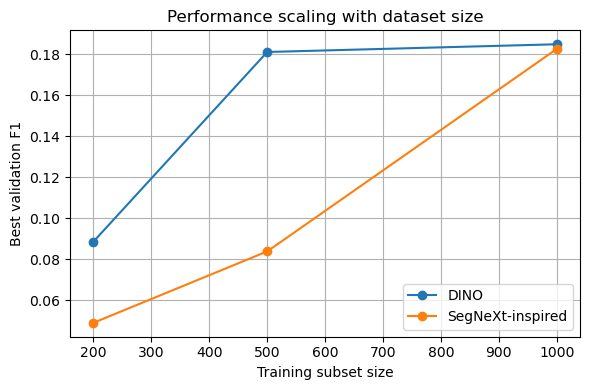

In [74]:
def best_for(model_name, train_size):
    subset = summary_df[(summary_df["model"] == model_name) & (summary_df["train_subset"] == train_size)]
    return subset.sort_values("best_val_f1", ascending=False).iloc[0]

sizes = [200, 500, 1000]
dino_f1 = [best_for("dino", s)["best_val_f1"] for s in sizes]
segnext_f1 = [best_for("segnext", s)["best_val_f1"] for s in sizes]

plt.figure(figsize=(6,4))
plt.plot(sizes, dino_f1, marker="o", label="DINO")
plt.plot(sizes, segnext_f1, marker="o", label="SegNeXt-inspired")
plt.xlabel("Training subset size")
plt.ylabel("Best validation F1")
plt.title("Performance scaling with dataset size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
def show_run_curves(run_name):
    run_dir = Path("outputs") / run_name
    loss_path = run_dir / "loss_curve.png"
    f1_path = run_dir / "f1_curve.png"

    print("\n", run_name)

    if loss_path.exists():
        plt.figure(figsize=(6, 4))
        plt.imshow(Image.open(loss_path))
        plt.axis("off")
        plt.title(f"{run_name} - Loss Curve")
        plt.show()

    if f1_path.exists():
        plt.figure(figsize=(6, 4))
        plt.imshow(Image.open(f1_path))
        plt.axis("off")
        plt.title(f"{run_name} - F1 Curve")
        plt.show()

In [76]:
small_dino_best = best_for("dino", 200)
small_seg_best = best_for("segnext", 200)

mid_dino_best = best_for("dino", 500)
mid_seg_best = best_for("segnext", 500)

large_dino_best = best_for("dino", 1000)
large_seg_best = best_for("segnext", 1000)

small_dino_best, small_seg_best, mid_dino_best, mid_seg_best, large_dino_best, large_seg_best

(run_name                      dino_lr0.0001_seed42_20260412_114751
 model                                                         dino
 lr                                                          0.0001
 epochs                                                           3
 train_subset                                                   200
 val_subset                                                      30
 effective_train_size                                           200
 effective_val_size                                              30
 segnext_encoder_source                                      custom
 segnext_timm_model_name                              convnext_tiny
 segnext_pretrained_encoder                                   False
 best_val_f1                                                0.08862
 best_epoch                                                       3
 Name: 0, dtype: object,
 run_name                      segnext_custom_lr0.0001_seed42_20260412_114922
 model       


 dino_lr0.0001_seed42_20260412_114751


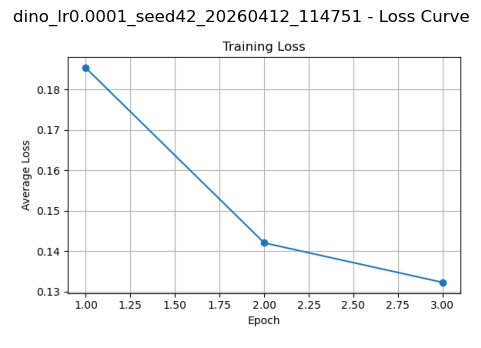

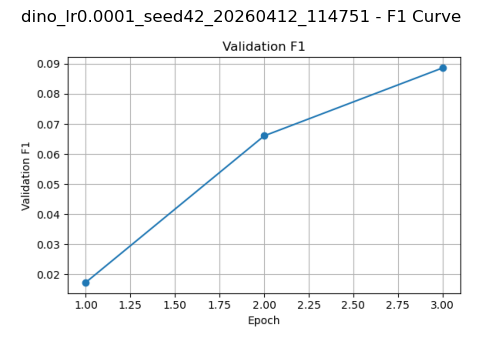


 segnext_custom_lr0.0001_seed42_20260412_114922


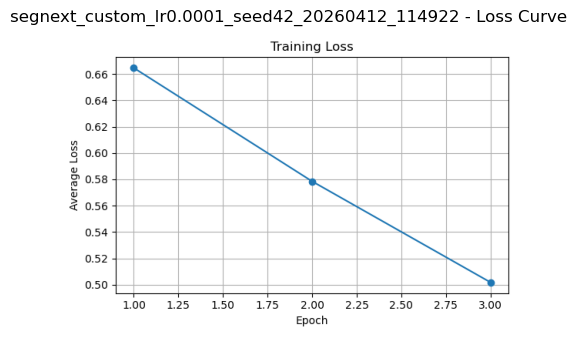

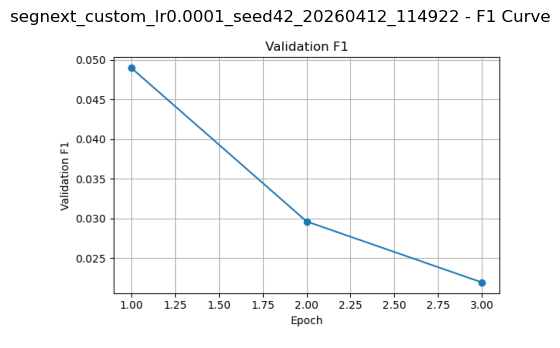


 dino_lr5e-05_seed42_20260412_115030


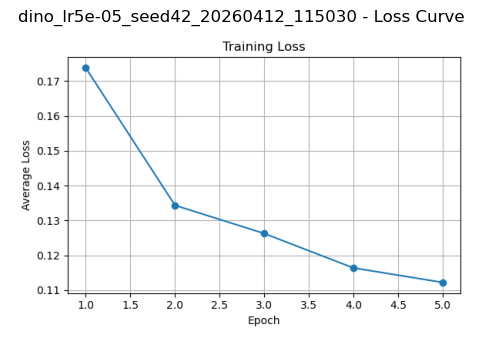

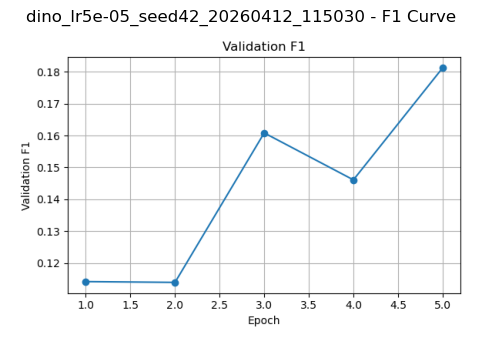


 segnext_custom_lr3e-05_seed42_20260412_120236


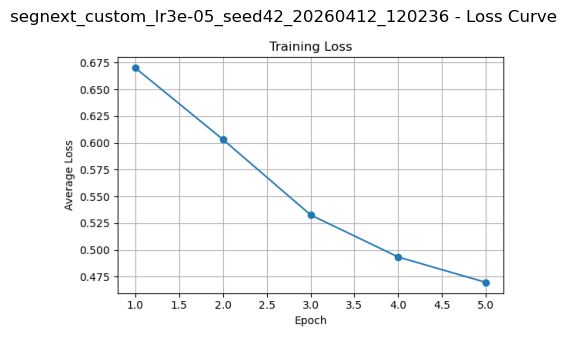

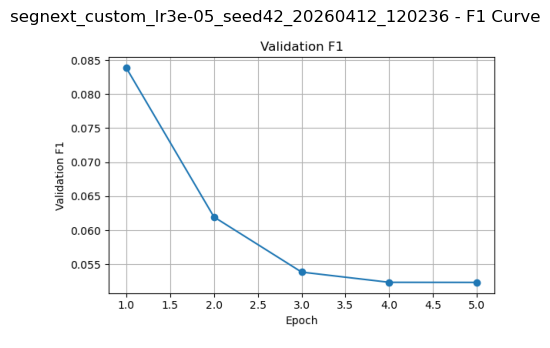


 dino_lr3e-05_seed42_20260412_120611


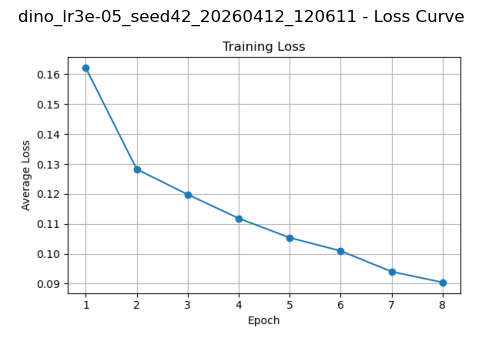

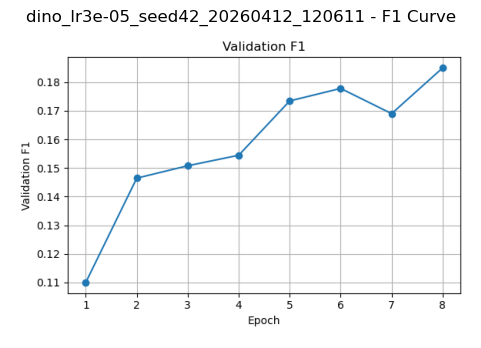


 segnext_convnext_tiny_pt_lr3e-05_seed42_20260412_130651


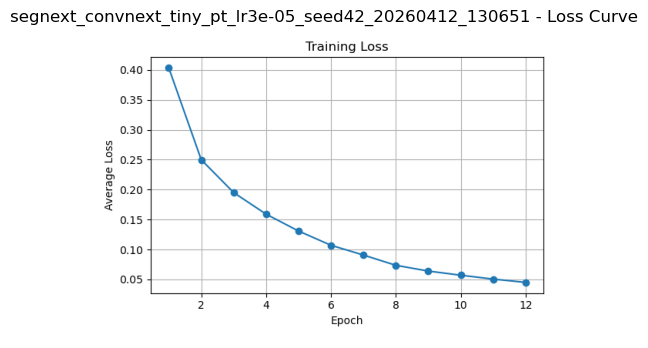

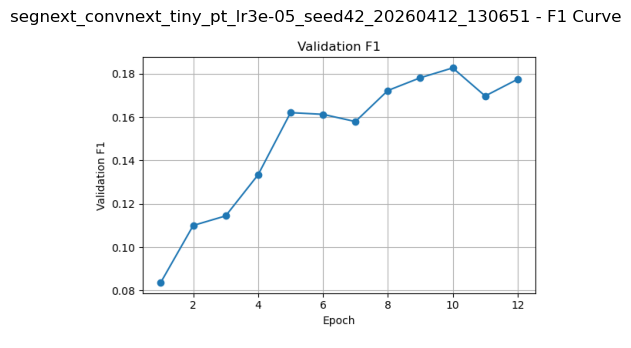

In [77]:
show_run_curves(small_dino_best["run_name"])
show_run_curves(small_seg_best["run_name"])
show_run_curves(mid_dino_best["run_name"])
show_run_curves(mid_seg_best["run_name"])
show_run_curves(large_dino_best["run_name"])
show_run_curves(large_seg_best["run_name"])

In [78]:
best_dino = summary_df[summary_df["model"] == "dino"].sort_values("best_val_f1", ascending=False).iloc[0]
best_seg = summary_df[summary_df["model"] == "segnext"].sort_values("best_val_f1", ascending=False).iloc[0]

text = f"""
Best DINO result: F1 = {best_dino['best_val_f1']:.4f}, effective_train_size = {best_dino['effective_train_size']}, lr = {best_dino['lr']}, epochs = {best_dino['epochs']}.  

Best SegNeXt-family result: F1 = {best_seg['best_val_f1']:.4f}, effective_train_size = {best_seg['effective_train_size']}, lr = {best_seg['lr']}, epochs = {best_seg['epochs']}.  
Encoder source = {best_seg['segnext_encoder_source']}, pretrained = {best_seg['segnext_pretrained_encoder']}, timm model = {best_seg['segnext_timm_model_name']}.

The notebook compares:
1. a DINO-based baseline,
2. a custom SegNeXt-inspired model,
3. a pretrained timm-backbone variant using the same lightweight decoder.
"""
display(Markdown(text))


Best DINO result: F1 = 0.1850, effective_train_size = 900, lr = 3e-05, epochs = 8.  

Best SegNeXt-family result: F1 = 0.1827, effective_train_size = 900, lr = 3e-05, epochs = 12.  
Encoder source = timm, pretrained = True, timm model = convnext_tiny.

The notebook compares:
1. a DINO-based baseline,
2. a custom SegNeXt-inspired model,
3. a pretrained timm-backbone variant using the same lightweight decoder.


In [5]:
import matplotlib.pyplot as plt

In [6]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(["train", "val"])
plt.savefig("loss_curve.png")

NameError: name 'train_loss' is not defined

In [4]:
plt.plot(val_f1)
plt.savefig("f1_curve.png")

NameError: name 'plt' is not defined